# Simulating the Trajectory

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defining parameters
k = 0.5 # mean reversion speed
theta = 0.05     # long-term mean level (5%)
sigma = 0.02     # volatility (2%)
r0 = 0.03        # initial interest rate (3%)

# Simulation parameters
T = 10           # time horizon (in years)
N = 1000         # number of time steps
dt = T/N         # time step size

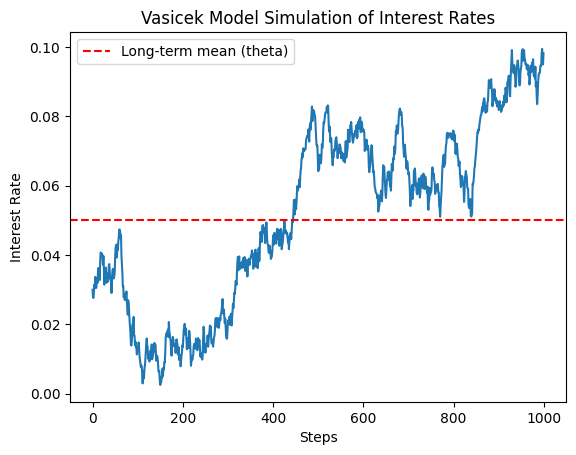

In [ ]:
# Single path simulation
r = np.zeros(N)
r[0] = r0
for i in range(1, N):
    dW = np.random.normal(0, np.sqrt(dt))
    r[i] = r[i-1] + k * (theta - r[i-1]) * dt + sigma * dW

# Chart
plt.plot(r)
plt.axhline(theta, color='red', linestyle='--', label='Long-term mean (theta)')
plt.xlabel('Steps')
plt.ylabel('Interest Rate')
plt.title('Vasicek Model Simulation of Interest Rates')
plt.legend()
plt.show()

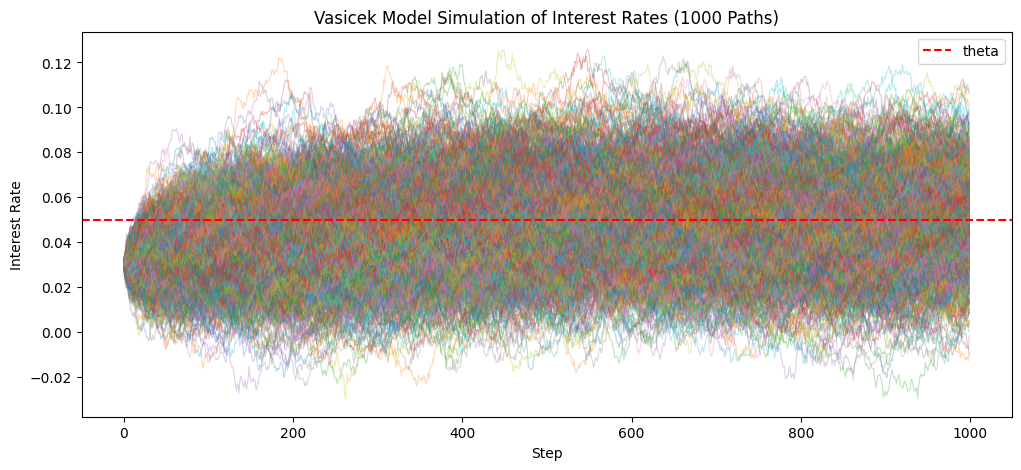

In [ ]:
# Multiple path simulation
n_paths = 100
r = np.zeros((N, n_paths))
r[0, :] = r0
for i in range(1, N):
    dW = np.random.normal(0, np.sqrt(dt), n_paths)
    r[i, :] = r[i-1, :] + k * (theta - r[i-1, :]) * dt + sigma * dW

# Chart
plt.figure(figsize=(12, 5))
plt.plot(r, alpha=0.3, linewidth=0.8)
plt.axhline(theta, color='red', linestyle='--', linewidth=1.5, label='theta')
plt.xlabel('Step')
plt.ylabel('Interest Rate')
plt.title(f'Vasicek Model Simulation of Interest Rates ({n_paths} Paths)')
plt.legend()
plt.show()

# Distribution and Statistics

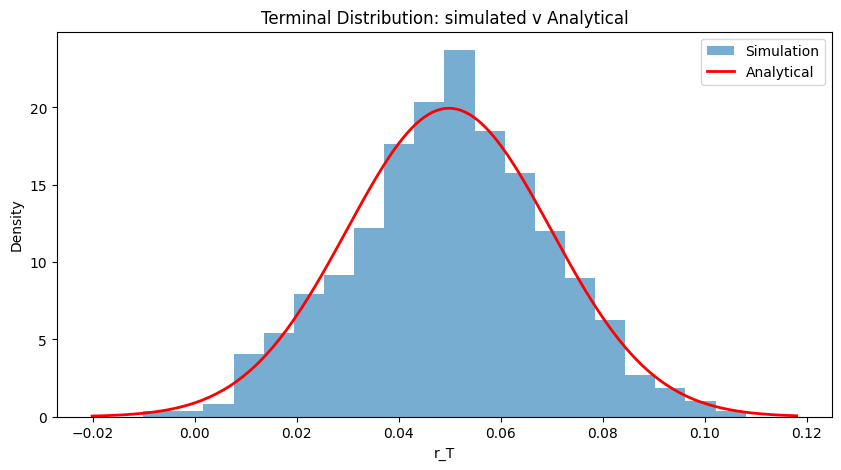

Simulated mean: 0.0502
Analytial mean: 0.0499
Simulated std:  0.0192
Analytical std: 0.0200


In [ ]:
# Simulated terminal values
r_T_sim = r[-1, :]

# Analytical solution
mean_analytical = theta + (r0 - theta) * np. exp(-k * T)
var_analytical  = (sigma**2 / (2 * k)) * (1 - np.exp(-2 * k * T))
std_analytical  = np.sqrt(var_analytical)

# Chart
x = np.linspace(r_T_sim.min() - 0.01, r_T_sim.max() + 0.01, 200)
pdf_analytical = (1 / (std_analytical * np.sqrt(2 * np.pi))) * \
                 np.exp(-0.5 * ((x - mean_analytical) / std_analytical)**2)

plt.figure(figsize=(10, 5))
plt.hist(r_T_sim, bins=20, density=True, alpha=0.6, label='Simulation')
plt.plot(x, pdf_analytical, color='red', linewidth=2, label='Analytical')
plt.xlabel('r_T')
plt.ylabel('Density')
plt.title('Terminal Distribution: simulated v Analytical')
plt.legend()
plt.show()

# Results
print(f'Simulated mean: {r_T_sim.mean():.4f}')
print(f'Analytial mean: {mean_analytical:.4f}')
print(f'Simulated std:  {r_T_sim.std():.4f}')
print(f'Analytical std: {std_analytical:.4f}')

# Bond Pricing

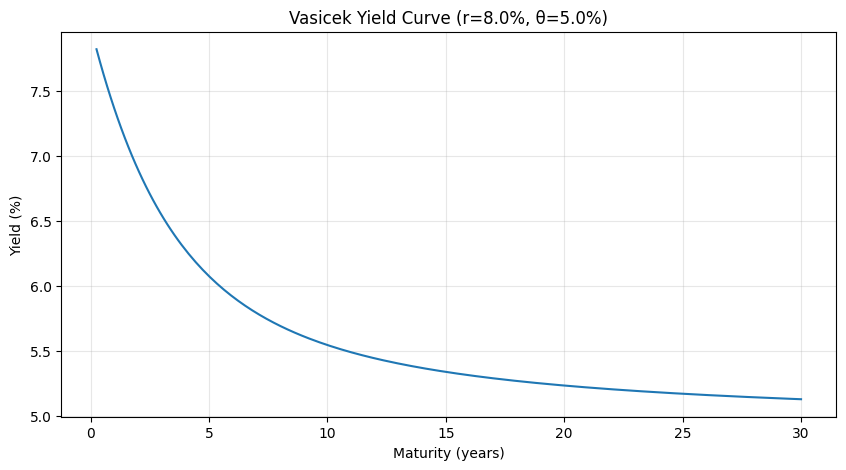

In [ ]:
def vasicek_bond_price(r, k, theta, sigma, tau):
  '''tau = T - t, time to maturity'''
  B = (1 - np.exp(-k * tau)) / k
  A = np.exp((theta - sigma**2 / (2 * k**2)) * (B - tau) - (sigma**2 / (2 * k)) * B**2)
  return A * np.exp(-B * r)

# 0.25 - 30 years Maturities
taus = np.linspace(0.25, 30, 200)
r_current = 0.08 # current observed rate

prices = vasicek_bond_price(r_current, k, theta, sigma, taus)
yields = -np.log(prices) / taus

plt.figure(figsize=(10, 5))
plt.plot(taus, yields * 100)
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title(f'Vasicek Yield Curve (r={r_current*100:.1f}%, θ={theta*100:.1f}%)')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Interactive widgets
import ipywidgets as widgets
from IPython.display import display

def plot_vasicek_yield_curve(k, theta, sigma, r_current):
    taus = np.linspace(0.25, 30, 200)
    prices = vasicek_bond_price(r_current, k, theta, sigma, taus)
    yields = -np.log(prices) / taus

    plt.figure(figsize=(10, 5))
    plt.plot(taus, yields * 100)
    plt.xlabel('Maturity (years)')
    plt.ylabel('Yield (%)')
    plt.title(f'Vasicek Yield Curve — r={r_current*100:.1f}%, θ={theta*100:.1f}%')
    plt.ylim(0, 15)
    plt.grid(alpha=0.3)
    plt.show()

widgets.interact(
    plot_vasicek_yield_curve,
    k=widgets.FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1, description='κ'),
    theta=widgets.FloatSlider(value=0.05, min=0.01, max=0.15, step=0.01, description='θ'),
    sigma=widgets.FloatSlider(value=0.02, min=0.01, max=0.10, step=0.01, description='σ'),
    r_current=widgets.FloatSlider(value=0.03, min=0.01, max=0.15, step=0.01, description='r₀')
)

interactive(children=(FloatSlider(value=0.5, description='κ', max=3.0, min=0.1), FloatSlider(value=0.05, descr…

<function __main__.plot_vasicek_yield_curve(k, theta, sigma, r_current)>

# Real data

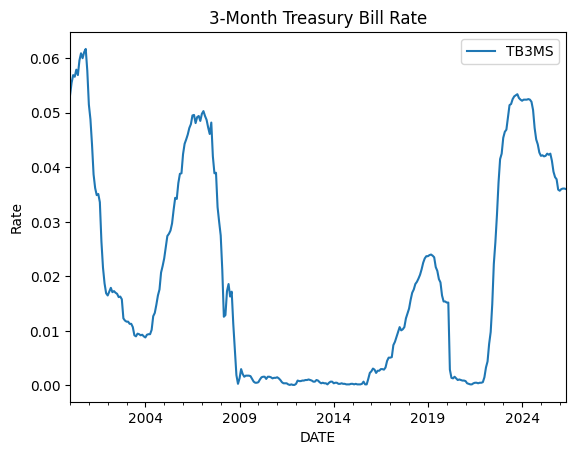

In [ ]:
# Integrating with real data
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(2000, 1, 1)
end = dt.datetime.today()

# 3-Month T-Bill: standard proxy for short-termr rate"
tb3m = web.DataReader('TB3MS', 'fred', start, end)
tb3m = tb3m / 100 # Convert to decimal
tb3m.plot(title='3-Month Treasury Bill Rate', ylabel='Rate')
plt.show()

In [ ]:
# Parameters estimation

# Series preparation
r_data = tb3m['TB3MS'].dropna().values
dt_data = 1/12 # monthly data

# Variables for regression: r_{t+1} - r_t = a + b * r_t
y = np.diff(r_data)     # r_{t+1} - r_t
x = r_data[:-1]         # r_t

# OLS
X = np.column_stack([np.ones(len(x)), x])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
a, b = beta

# Vasicek parameters
k_est     = -b / dt_data
theta_est = a/ (-b)
residuals = y - (a + b * x)
sigma_est = residuals.std() / np.sqrt(dt_data)

print(f"κ (mean reversion): {k_est:.4f}")
print(f"θ (long-run mean):  {theta_est:.4f} ({theta_est*100:.2f}%)")
print(f"σ (volatiliy):     {sigma_est:.4f}")
print(f"r0 (last value): {r_data[-1]:.4f} ({r_data[-1]*100:.2f}%)")

κ (mean reversion): 0.1023
θ (long-run mean):  0.0127 (1.27%)
σ (volatiliy):     0.0065
r0 (last value): 0.0360 (3.60%)


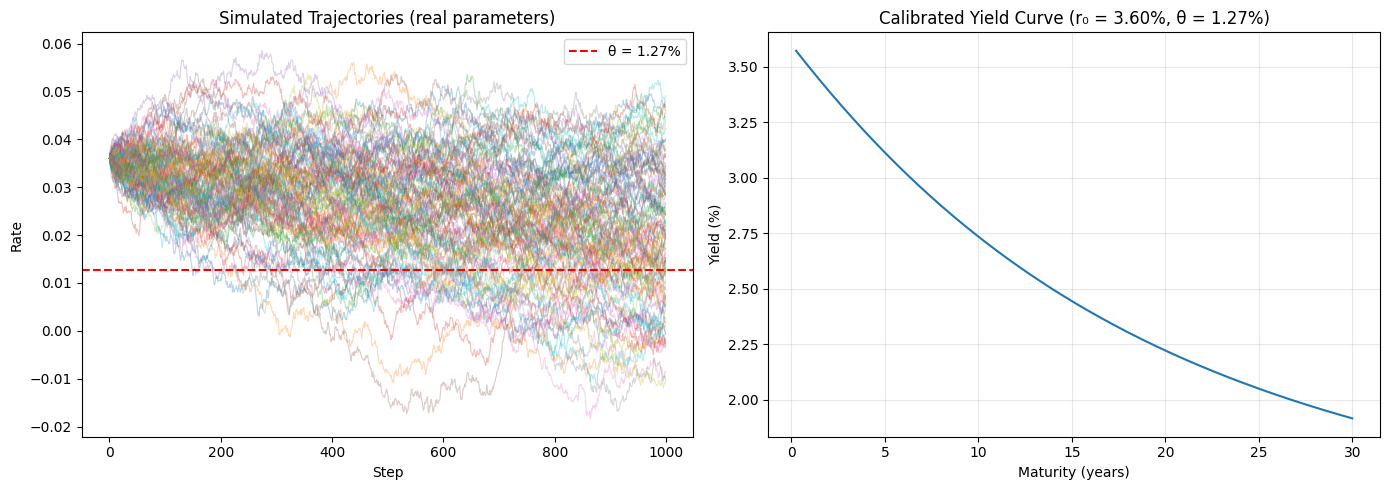

In [ ]:
# Simulation using estimated parameters

k = k_est
theta = theta_est
sigma = sigma_est
r0    = r_data[-1]

# Simulation
T      = 10
N      = 1000
dt     = T / N
n_paths = 100

r_sim = np.zeros((N, n_paths))
r_sim[0, :] = r0

for i in range(1, N):
    dW = np.random.normal(0, np.sqrt(dt), n_paths)
    r_sim[i, :] = r_sim[i-1, :] + k * (theta - r_sim[i-1, :]) * dt + sigma * dW

# Calibrated Yield Curve
taus = np.linspace(0.25, 30, 200)
prices = vasicek_bond_price(r0, k, theta, sigma, taus)
yields = -np.log(prices) / taus

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(r_sim, alpha=0.3, linewidth=0.8)
axes[0].axhline(theta, color='red', linestyle='--', linewidth=1.5, label=f'θ = {theta:.2%}')
axes[0].set_title('Simulated Trajectories (real parameters)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Rate')
axes[0].legend()

axes[1].plot(taus, yields * 100)
axes[1].set_title(f'Calibrated Yield Curve (r₀ = {r0:.2%}, θ = {theta:.2%})')
axes[1].set_xlabel('Maturity (years)')
axes[1].set_ylabel('Yield (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()